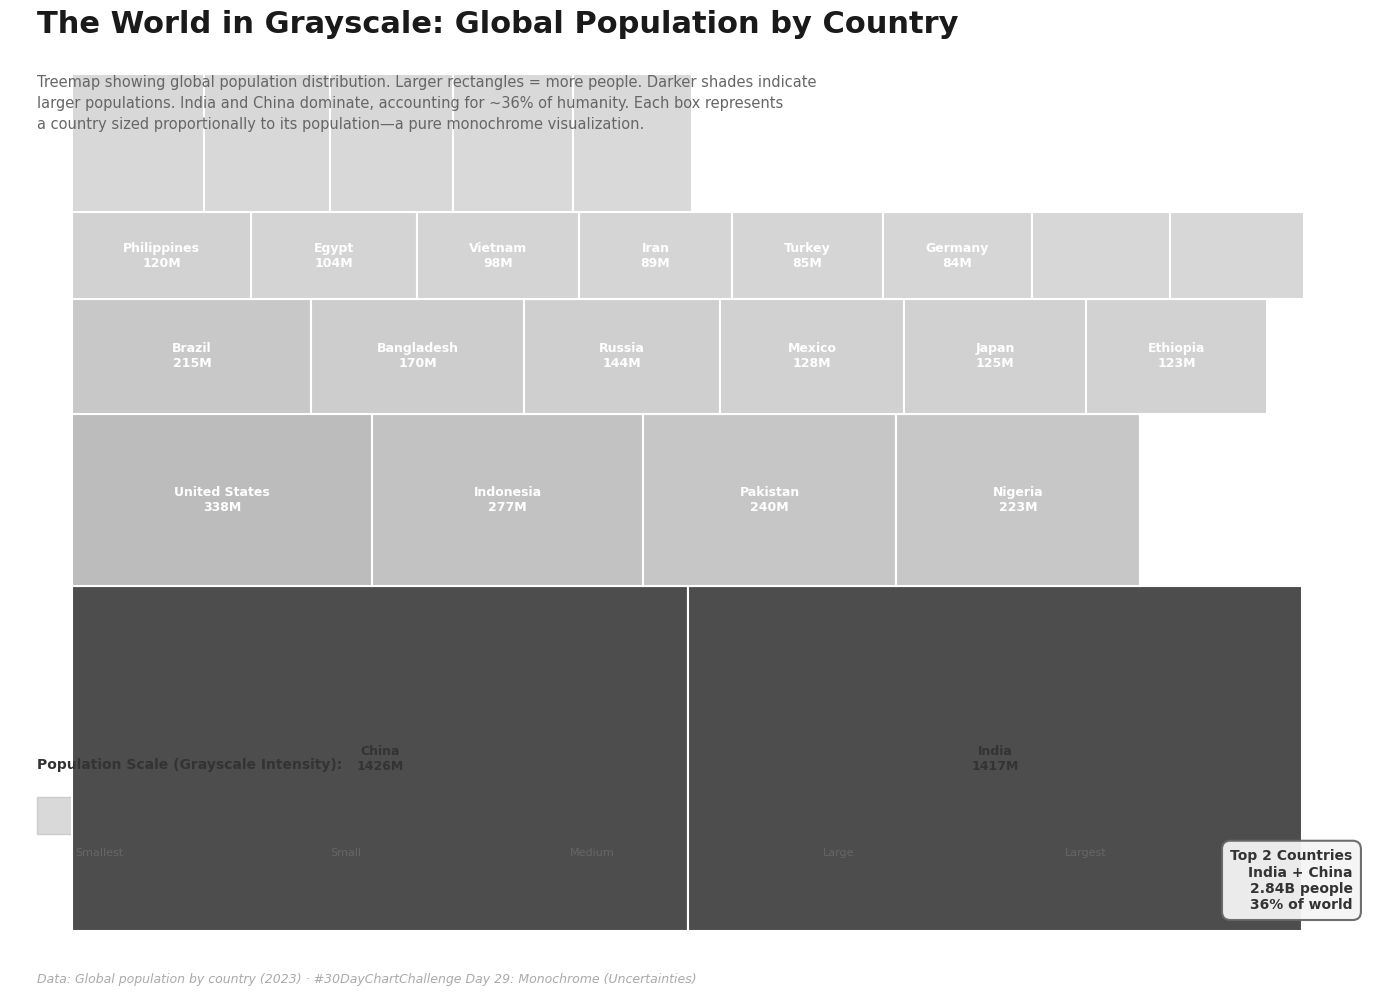

In [1]:
"""
#30DayChartChallenge — Day 29: Monochrome (Uncertainties)
"The World in Grayscale: Global Population by Country" — treemap in pure monochrome
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Population distribution across major countries (2023)
Constraint: Single color (grayscale) only
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Population by country (Millions)
# ---------------------------------------------------------------------------
data = {
    "Country": [
        "India", "China", "United States", "Indonesia", "Pakistan",
        "Brazil", "Nigeria", "Bangladesh", "Russia", "Mexico",
        "Japan", "Ethiopia", "Philippines", "Egypt", "Vietnam",
        "Iran", "Turkey", "Germany", "Thailand", "France",
        "Tanzania", "South Africa", "Italy", "Myanmar", "Kenya"
    ],
    "Population": [
        1417, 1426, 338, 277, 240,
        215, 223, 170, 144, 128,
        125, 123, 120, 104, 98,
        89, 85, 84, 71, 68,
        65, 60, 57, 54, 53
    ],
    "Region": [
        "Asia", "Asia", "Americas", "Asia", "Asia",
        "Americas", "Africa", "Asia", "Europe", "Americas",
        "Asia", "Africa", "Asia", "Africa", "Asia",
        "Asia", "Asia", "Europe", "Asia", "Europe",
        "Africa", "Africa", "Europe", "Asia", "Africa"
    ]
}

df = pd.DataFrame(data)
df = df.sort_values("Population", ascending=False)

# ---------------------------------------------------------------------------
# 2. PLOT — Treemap in pure monochrome (grayscale)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Normalize population for grayscale mapping (0 = light gray, 1 = black)
pop_min = df["Population"].min()
pop_max = df["Population"].max()
normalized_pop = (df["Population"] - pop_min) / (pop_max - pop_min)

# Create grayscale colors (inverted: larger = darker)
# Map to range [0.3, 0.85] to avoid pure white and pure black
grayscale_colors = [0.3 + (1 - val) * 0.55 for val in normalized_pop]

# Create treemap manually using rectangles
# Simple grid layout based on population
total_pop = df["Population"].sum()
proportions = df["Population"] / total_pop

# Arrange in rough grid
x_pos = 0
y_pos = 0
max_width = 10
current_row_height = 0
row_items = []
current_row_width = 0
current_row = []

for idx, (i, row) in enumerate(df.iterrows()):
    width = np.sqrt(proportions.iloc[idx]) * max_width
    
    if current_row_width + width > max_width and current_row:
        # Start new row
        row_items.append(current_row)
        current_row = []
        current_row_width = 0
        y_pos += current_row_height
        current_row_height = 0
    
    current_row.append((row["Country"], row["Population"], width, grayscale_colors[idx]))
    current_row_width += width

if current_row:
    row_items.append(current_row)

# Draw rectangles
y = 0
for row in row_items:
    row_height = max_width / len(row) * 1.5 if len(row) > 0 else 1
    x = 0
    
    for country, pop, width, gray_val in row:
        rect = mpatches.Rectangle((x, y), width, row_height, 
                                  facecolor=(gray_val, gray_val, gray_val),
                                  edgecolor="white", linewidth=1.5, zorder=2)
        ax.add_patch(rect)
        
        # Add text label
        if pop > 80:  # Only label significant populations
            ax.text(x + width/2, y + row_height/2, f"{country}\n{pop:.0f}M",
                   fontsize=9, fontweight="600", color="white" if gray_val > 0.5 else "#333333",
                   ha="center", va="center", zorder=3)
        
        x += width
    
    y += row_height

# Minimal styling
ax.set_xlim(-0.5, max_width + 0.5)
ax.set_ylim(-0.5, y + 1)
ax.axis("off")

# Title & subtitle
ax.text(0.02, 1.02, "The World in Grayscale: Global Population by Country",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.95,
        "Treemap showing global population distribution. Larger rectangles = more people. Darker shades indicate\n"
        "larger populations. India and China dominate, accounting for ~36% of humanity. Each box represents\n"
        "a country sized proportionally to its population—a pure monochrome visualization.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Legend: grayscale intensity
legend_y = 0.20
ax.text(0.02, legend_y, "Population Scale (Grayscale Intensity):",
        fontsize=10, color="#333333", fontweight="600", transform=ax.transAxes)

for i, label in enumerate(["Smallest", "Small", "Medium", "Large", "Largest"]):
    gray = 0.3 + (1 - i/4) * 0.55
    rect = mpatches.Rectangle((0.02 + i*0.18, legend_y - 0.07), 0.04, 0.04,
                              facecolor=(gray, gray, gray), edgecolor="#cccccc", linewidth=1,
                              transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(0.065 + i*0.18, legend_y - 0.085, label,
           fontsize=8, color="#666666", transform=ax.transAxes, ha="center", va="top")

# Key stat
ax.text(0.98, 0.08, "Top 2 Countries\nIndia + China\n2.84B people\n36% of world",
        fontsize=10, color="#333333", fontweight="bold", transform=ax.transAxes, 
        ha="right", va="center",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#f5f5f5", edgecolor="#666666", linewidth=1.5, alpha=0.95))

# Source
ax.text(0.02, -0.02,
        "Data: Global population by country (2023) · #30DayChartChallenge Day 29: Monochrome (Uncertainties)",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="top")

plt.tight_layout()
plt.savefig("day29_monochrome.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()